CELL 1 Koneksi ke Google Drive & Persiapan Folder

In [ ]:
# ==========================================
# TAHAP 1: MOUNT DRIVE & SETUP FOLDER
# ==========================================
from google.colab import drive
import os

print("🔄 Menyambungkan ke Google Drive...")
drive.mount('/content/drive')

# Path ke folder kits23 milik Anda (sesuai screenshot)
work_dir = '/content/drive/MyDrive/kits23'

# Cek apakah folder ada dan pindah ke sana
if os.path.exists(work_dir):
    os.chdir(work_dir)
    print(f"✅ Berhasil masuk ke direktori: {os.getcwd()}")
    print("📂 Isi folder saat ini:", os.listdir('.'))
else:
    print("❌ ERROR: Folder 'kits23' tidak ditemukan di MyDrive! Pastikan nama foldernya benar.")

CELL 2 Instalasi Library & Alat Downloader KiTS23

In [ ]:
# ==========================================
# TAHAP 2: INSTALASI ALAT & LIBRARY
# ==========================================
import sys

print("⏳ Menginstall alat downloader KiTS23 dari local file...")
!pip install -e .

print("\n⏳ Menginstall library AI & Medis pendukung...")
!pip install nibabel monai seaborn openpyxl scikit-learn

print("\n✅ Semua instalasi selesai! Siap mengunduh data.")

CELL 3 Proses Download 489 Dataset Asli

In [ ]:
# ==========================================
# TAHAP 3: DOWNLOAD DATASET (VERSI NATIVE PYTHON)
# ==========================================
import time
from kits23.download import download_dataset

print("🚀 MEMULAI DOWNLOAD 489 DATASET KITS23...")
print("🛡️ Sistem Auto-Retry AKTIF: Langsung menyambung dari titik terakhir jika server putus.\n")

while True:
    try:
        # Memanggil fungsi inti downloader secara langsung
        download_dataset()
        print("\n✅ DOWNLOAD SELESAI 100%! Data berhasil tersimpan di Google Drive Anda.")
        break # Keluar dari loop jika sukses
    except Exception as e:
        print(f"\n⚠️ Server tersendat. Error detail: {e}")
        print("🔄 Tenang, sistem akan meresume ulang dalam 5 detik...")
        time.sleep(5)

CELL 4 Definisi Dataset Loader (Hemat RAM)

In [ ]:
# ==========================================
# TAHAP 4: DATASET LOADER (.nii.gz)
# ==========================================
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Menggunakan Device: {device}")

class KiTS23Dataset(Dataset):
    def __init__(self, root_dir, max_cases=None):
        self.root_dir = root_dir
        self.cases = []

        # Folder default unduhan biasanya bernama 'data' atau 'dataset'
        data_dir = os.path.join(root_dir, 'data')
        if not os.path.exists(data_dir):
            data_dir = root_dir # Fallback

        candidates = sorted([d for d in os.listdir(data_dir) if d.startswith('case_')])
        if max_cases: candidates = candidates[:max_cases]

        print("🔍 Memindai folder pasien...")
        for case in candidates:
            c_path = os.path.join(data_dir, case)
            if os.path.exists(os.path.join(c_path, 'imaging.nii.gz')) and \
               os.path.exists(os.path.join(c_path, 'segmentation.nii.gz')):
                self.cases.append(c_path)

        print(f"✅ Siap dilatih dengan {len(self.cases)} Pasien.")

    def __len__(self): return len(self.cases)

    def __getitem__(self, idx):
        path = self.cases[idx]
        try:
            img = nib.load(os.path.join(path, 'imaging.nii.gz')).get_fdata()
            mask = nib.load(os.path.join(path, 'segmentation.nii.gz')).get_fdata()

            # Ambil irisan tengah (Slice 2D)
            if len(img.shape) == 3:
                z = img.shape[0] // 2
                img = img[z]; mask = mask[z]

            # Crop/Pad ke 256x256
            h, w = img.shape
            img_resized = np.zeros((256, 256), dtype=np.float32)
            mask_resized = np.zeros((256, 256), dtype=np.uint8)

            crop_h, crop_w = min(h, 256), min(w, 256)
            st_h, st_w = (h - crop_h)//2, (w - crop_w)//2

            img_resized[:crop_h, :crop_w] = img[st_h:st_h+crop_h, st_w:st_w+crop_w]
            mask_resized[:crop_h, :crop_w] = mask[st_h:st_h+crop_h, st_w:st_w+crop_w]

            # Normalisasi HU (-150 to 250)
            img_resized = np.clip(img_resized, -150, 250)
            img_resized = (img_resized - (-150)) / 400.0

            return torch.tensor(img_resized).unsqueeze(0).float(), torch.tensor(mask_resized).long()
        except Exception as e:
            return torch.zeros((1,256,256)), torch.zeros((256,256)).long()

CELL 5 Arsitektur Model & Metrik Evaluasi

In [ ]:
# ==========================================
# TAHAP 5: ARSITEKTUR MODEL & METRIK
# ==========================================
import torch.nn as nn
import torch.nn.functional as F

# --- 1. U-NET STANDAR (SEBAGAI PEMBANDING) ---
class UNetStandard(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        def cb(in_c, out_c): return nn.Sequential(nn.Conv2d(in_c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True), nn.Conv2d(out_c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))
        self.e1 = cb(1, 64); self.p1 = nn.MaxPool2d(2)
        self.e2 = cb(64, 128); self.p2 = nn.MaxPool2d(2)
        self.b = cb(128, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.d2 = cb(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.d1 = cb(128, 64)
        self.out = nn.Conv2d(64, n_classes, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); b = self.b(self.p2(x2))
        d2 = self.d2(torch.cat([self.u2(b), x2], dim=1))
        d1 = self.d1(torch.cat([self.u1(d2), x1], dim=1))
        return self.out(d1)

# --- 2. HYBRID RESIDUAL-ATTENTION U-NET (USULAN SKRIPSI) ---
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_c, out_c, 3, stride, 1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True), nn.Conv2d(out_c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c))
        self.skip = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride), nn.BatchNorm2d(out_c)) if in_c != out_c or stride != 1 else nn.Identity()
    def forward(self, x): return F.relu(self.conv(x) + self.skip(x))

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
    def forward(self, g, x): return x * self.psi(F.relu(self.W_g(g) + self.W_x(x)))

class HybridUNet(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.e1 = ResBlock(1, 64); self.p1 = nn.MaxPool2d(2)
        self.e2 = ResBlock(64, 128); self.p2 = nn.MaxPool2d(2)
        self.b = ResBlock(128, 256)
        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2); self.ag2 = AttentionGate(128, 128, 64); self.d2 = ResBlock(256, 128)
        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2); self.ag1 = AttentionGate(64, 64, 32); self.d1 = ResBlock(128, 64)
        self.out = nn.Conv2d(64, n_classes, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); b = self.b(self.p2(x2))
        d2 = self.u2(b); x2_att = self.ag2(d2, x2); d2 = self.d2(torch.cat([d2, x2_att], dim=1))
        d1 = self.u1(d2); x1_att = self.ag1(d1, x1); d1 = self.d1(torch.cat([d1, x1_att], dim=1))
        return self.out(d1)

# --- 3. METRIK ---
def calc_metrics(pred, target):
    pred = torch.argmax(pred, dim=1)
    # Metrik Tumor (Label 2)
    p_t = (pred == 2); t_t = (target == 2)
    inter = (p_t & t_t).sum().item(); union = (p_t | t_t).sum().item()
    dice = (2 * inter) / (p_t.sum().item() + t_t.sum().item() + 1e-8)
    iou = inter / (union + 1e-8)
    return dice, iou

CELL 6 Training Loop (Perbandingan 2 Model)

In [ ]:
# ==========================================
# TAHAP 6: PELATIHAN MODEL (TRAINING KOMPARASI)
# ==========================================
import pandas as pd
import os
import torch
from tqdm import tqdm

# Atur parameter
EPOCHS = 10
BATCH_SIZE = 4

# Arahkan ke folder dataset
path_data_benar = os.path.join(work_dir, 'dataset')
dataset = KiTS23Dataset(path_data_benar, max_cases=None)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

models = {'U-Net Standar': UNetStandard(3).to(device), 'Hybrid U-Net': HybridUNet(3).to(device)}
history = []

criterion = torch.nn.CrossEntropyLoss()

for model_name, model in models.items():
    print(f"\n🚀 MEMULAI TRAINING: {model_name}")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(EPOCHS):
        model.train()
        ep_loss, ep_dice, ep_iou = 0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for img, mask in pbar:
            img, mask = img.to(device), mask.to(device)

            # ---------------------------------------------------------
            # PERBAIKAN: Saring label Kista (3) menjadi Background (0)
            # ---------------------------------------------------------
            mask[mask > 2] = 0

            optimizer.zero_grad()
            out = model(img)
            loss = criterion(out, mask)
            loss.backward()
            optimizer.step()

            d, i = calc_metrics(out, mask)
            ep_loss += loss.item(); ep_dice += d; ep_iou += i
            pbar.set_postfix({'Loss': f"{loss.item():.3f}"})

        history.append({
            'Model': model_name, 'Epoch': epoch+1,
            'Loss': ep_loss/len(train_loader),
            'Dice': ep_dice/len(train_loader), 'IoU': ep_iou/len(train_loader)
        })

df_history = pd.DataFrame(history)
print("\n✅ PELATIHAN KEDUA MODEL SELESAI!")

🔍 Memindai folder pasien...
✅ Siap dilatih dengan 488 Pasien.

🚀 MEMULAI TRAINING: U-Net Standar


Epoch 10/10: 100%|██████████| 122/122 [25:10<00:00, 12.38s/it, Loss=0.104]



🚀 MEMULAI TRAINING: Hybrid U-Net


Epoch 10/10: 100%|██████████| 122/122 [25:47<00:00, 12.69s/it, Loss=0.058]


✅ PELATIHAN KEDUA MODEL SELESAI!


CELL 7 Menampilkan Grafik Akurasi & Loss

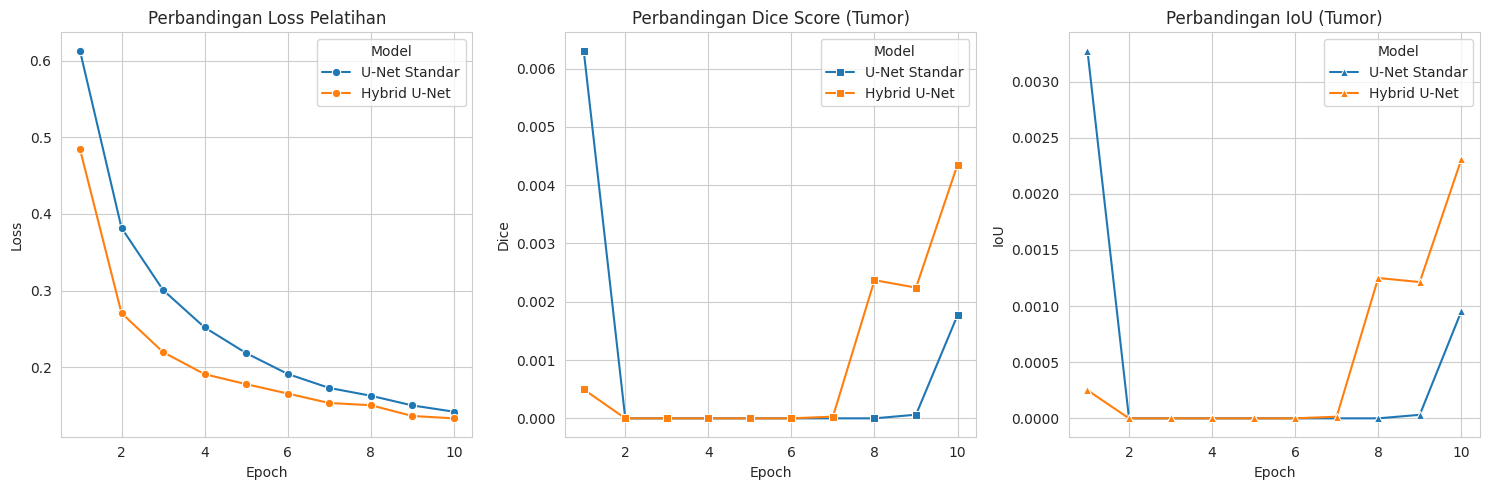

✅ Grafik berhasil disimpan: 'Grafik_Evaluasi_Skripsi.png'


In [ ]:
# ==========================================
# TAHAP 7: GRAFIK AKURASI & LOSS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))
sns.set_style("whitegrid")

# Grafik 1: Loss
plt.subplot(1, 3, 1)
sns.lineplot(data=df_history, x='Epoch', y='Loss', hue='Model', marker="o")
plt.title('Perbandingan Loss Pelatihan')

# Grafik 2: Dice Score
plt.subplot(1, 3, 2)
sns.lineplot(data=df_history, x='Epoch', y='Dice', hue='Model', marker="s")
plt.title('Perbandingan Dice Score (Tumor)')

# Grafik 3: IoU
plt.subplot(1, 3, 3)
sns.lineplot(data=df_history, x='Epoch', y='IoU', hue='Model', marker="^")
plt.title('Perbandingan IoU (Tumor)')

plt.tight_layout()
plt.savefig('Grafik_Evaluasi_Skripsi.png', dpi=300)
plt.show()
print("✅ Grafik berhasil disimpan: 'Grafik_Evaluasi_Skripsi.png'")

CELL 8 Menampilkan Confusion Matrix

📊 Menghitung Confusion Matrix untuk Model Hybrid...


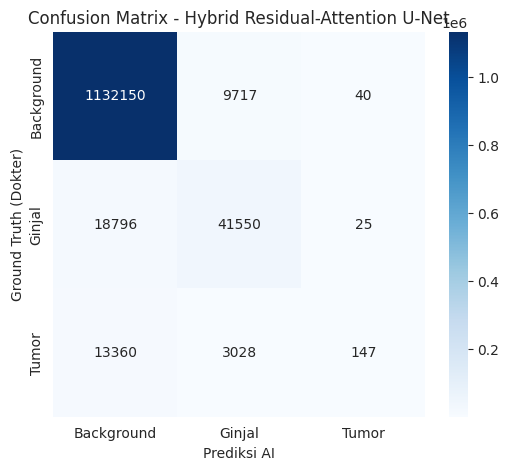

In [ ]:
# ==========================================
# TAHAP 8: CONFUSION MATRIX (PIXEL-LEVEL)
# ==========================================
from sklearn.metrics import confusion_matrix

print("📊 Menghitung Confusion Matrix untuk Model Hybrid...")
models['Hybrid U-Net'].eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for img, mask in train_loader:
        img = img.to(device)
        out = models['Hybrid U-Net'](img)
        pred = torch.argmax(out, dim=1).cpu().numpy().flatten()
        target = mask.numpy().flatten()

        # Ambil sampel subset piksel agar RAM tidak penuh
        idx = np.random.choice(len(pred), 10000, replace=False)
        all_preds.extend(pred[idx]); all_targets.extend(target[idx])

cm = confusion_matrix(all_targets, all_preds, labels=[0, 1, 2])
labels = ['Background', 'Ginjal', 'Tumor']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Hybrid Residual-Attention U-Net')
plt.xlabel('Prediksi AI'); plt.ylabel('Ground Truth (Dokter)')
plt.savefig('Confusion_Matrix_Skripsi.png', dpi=300)
plt.show()

CELL 19 Visualisasi Perbandingan (Gambar Segmentasi)



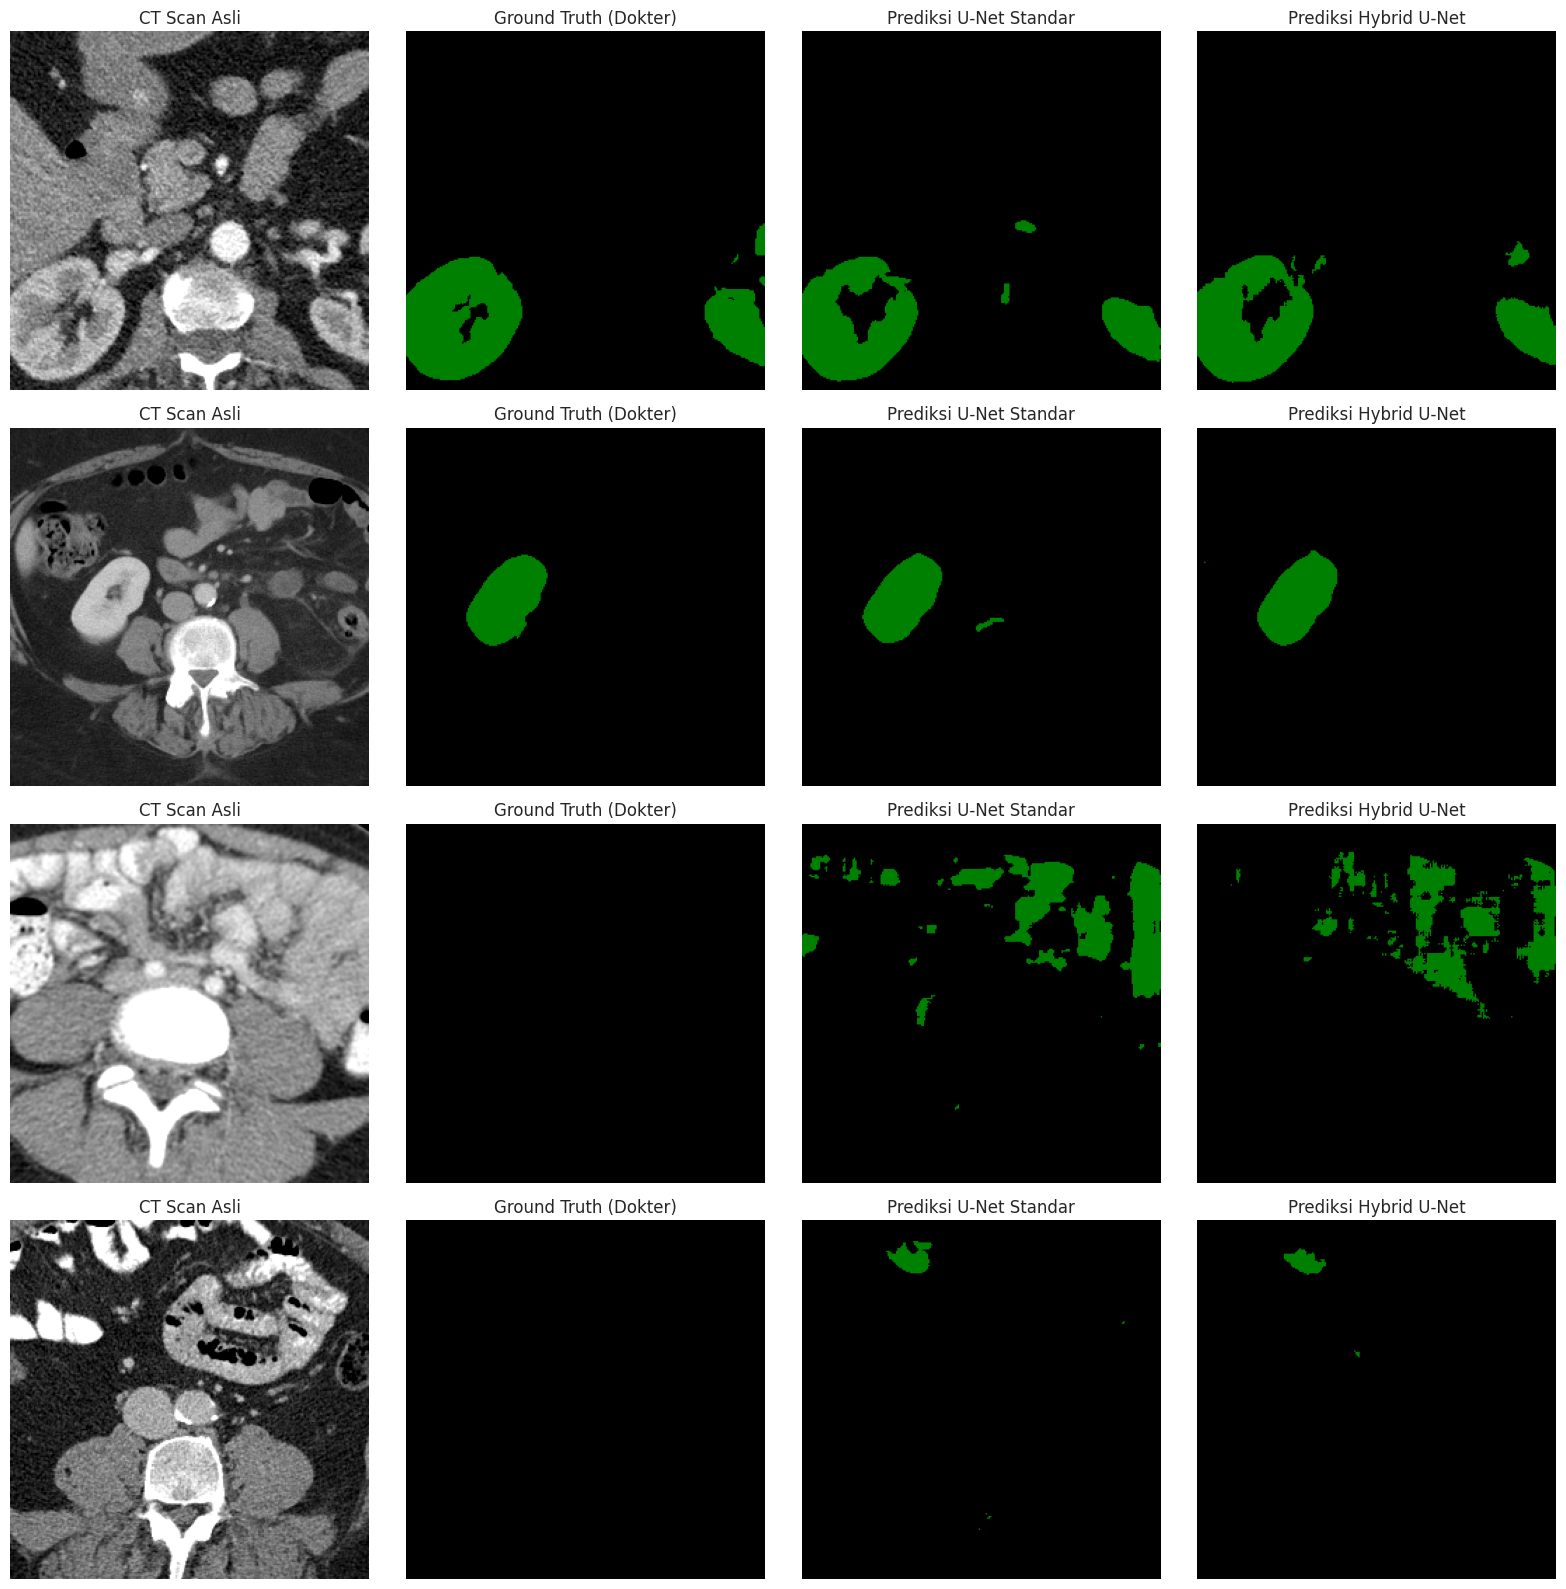

In [ ]:
# ==========================================
# TAHAP 9: VISUALISASI HASIL SEGMENTASI
# ==========================================
from matplotlib.colors import ListedColormap

# Ambil 1 batch data
img, mask = next(iter(train_loader))
img, mask = img.to(device), mask.to(device)

# Prediksi kedua model
with torch.no_grad():
    pred_unet = torch.argmax(models['U-Net Standar'](img), dim=1)
    pred_hybrid = torch.argmax(models['Hybrid U-Net'](img), dim=1)

cmap = ListedColormap(['black', 'green', 'red']) # 0=BG, 1=Ginjal, 2=Tumor
fig, axes = plt.subplots(min(4, len(img)), 4, figsize=(16, 4 * min(4, len(img))))

for i in range(min(4, len(img))):
    axes[i, 0].imshow(img[i, 0].cpu(), cmap='gray')
    axes[i, 0].set_title("CT Scan Asli")
    axes[i, 1].imshow(mask[i].cpu(), cmap=cmap, vmin=0, vmax=2)
    axes[i, 1].set_title("Ground Truth (Dokter)")
    axes[i, 2].imshow(pred_unet[i].cpu(), cmap=cmap, vmin=0, vmax=2)
    axes[i, 2].set_title("Prediksi U-Net Standar")
    axes[i, 3].imshow(pred_hybrid[i].cpu(), cmap=cmap, vmin=0, vmax=2)
    axes[i, 3].set_title("Prediksi Hybrid U-Net")
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('Visualisasi_Perbandingan_Skripsi.png', dpi=300)
plt.show()

CELL 10 Ekspor Tabel Hasil ke File Excel

In [ ]:
# ==========================================
# TAHAP 10: EKSPOR DATA KE EXCEL
# ==========================================
excel_name = ''

# Menyimpan dataframe ke excel
df_history.to_excel(excel_name, index=False)

print(f"✅ BUKTI DATA SKRIPSI BERHASIL DISIMPAN!")
print(f"📁 Nama file Excel : {excel_name}")
print("\nAnda dapat mendownload file Excel dan gambar-gambar PNG melalui panel 'Files' (ikon folder) di sebelah kiri layar Colab.")

# Tampilkan beberapa baris pertama sebagai sampel di layar
display(df_history.head(6))

In [ ]:
# ==========================================
# CELL 11: 6 SAMPEL HORIZONTAL (FOKUS AREA TUMOR)
# ==========================================
import matplotlib.pyplot as plt
import torch
import numpy as np

print("🔍 Memindai ratusan irisan, mencari 6 gambar yang WAJIB mengandung TUMOR...")

sample_imgs = []
sample_masks = []

# SMART FILTER: Hanya ambil gambar yang ada TUMOR-nya (Label = 2)
with torch.no_grad():
    for imgs, masks in train_loader:
        for i in range(imgs.size(0)):
            if masks[i].max() == 2:  # <-- Syarat ketat: Harus ada tumor (2)
                sample_imgs.append(imgs[i].unsqueeze(0))
                sample_masks.append(masks[i].unsqueeze(0))

            if len(sample_imgs) == 6:
                break
        if len(sample_imgs) == 6:
            break

# Gabungkan jadi 1 batch untuk diproses AI
sample_imgs = torch.cat(sample_imgs, dim=0).to(device)
sample_masks = torch.cat(sample_masks, dim=0).numpy()

# Minta AI (Hanya Model Hybrid) menebak gambar
models['Hybrid U-Net'].eval()
with torch.no_grad():
    pred_hybrid = torch.argmax(models['Hybrid U-Net'](sample_imgs), dim=1).cpu().numpy()

images_np = sample_imgs.cpu().numpy()

# Buat kanvas 6 Baris x 3 Kolom (Lebih lebar / horizontal)
fig, axes = plt.subplots(6, 3, figsize=(15, 20))

for i in range(6):
    # 1. CT Scan Asli
    axes[i, 0].imshow(images_np[i, 0], cmap='gray')
    axes[i, 0].axis('off')
    if i == 0: axes[i, 0].set_title('CT Scan Asli', fontsize=16, fontweight='bold')

    # 2. Kunci Jawaban (Ground Truth Dokter)
    axes[i, 1].imshow(sample_masks[i], cmap='nipy_spectral', vmin=0, vmax=2)
    axes[i, 1].axis('off')
    if i == 0: axes[i, 1].set_title('Ground Truth Dokter\n(Hijau: Ginjal, Abu: Tumor)', fontsize=14, fontweight='bold')

    # 3. Prediksi Hybrid U-Net (Usulan Anda)
    axes[i, 2].imshow(pred_hybrid[i], cmap='nipy_spectral', vmin=0, vmax=2)
    axes[i, 2].axis('off')
    if i == 0: axes[i, 2].set_title('Prediksi Hybrid U-Net', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('Visualisasi_6_Sampel_Tumor.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 6 Sampel FOKUS TUMOR berhasil dieksekusi!")
print("✅ Gambar tersimpan sebagai: 'Visualisasi_6_Sampel_Tumor.png'")